# Modelación definitiva con train, validation y test

Este notebook compara tres algoritmos utilizando validation, optimiza Random Forest sin consultar test y reserva el conjunto de prueba para una única evaluación final.

## Librerías necesarias

Se utilizarán herramientas de Pandas y NumPy para cargar los datos, pipelines para evitar inconsistencias en el escalado y Scikit-learn para entrenar y evaluar los modelos.


In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set_theme(style="white")


## 1. Tipo de problema

El objetivo es predecir cuál de las 16 actividades de entrenamiento se está realizando a partir de características obtenidas de las señales. Como cada observación tiene una etiqueta conocida durante el entrenamiento, se trata de **aprendizaje supervisado** y **clasificación multiclase**.

La salida esperada es una sola etiqueta de actividad, entre `000` y `015`, para cada ventana de entrada.


## 2. Tipo de datos y modelos compatibles

Cada fila representa una ventana de 220 puntos resumida mediante 120 características numéricas: diez estadísticas para cada uno de los 12 canales. La columna `actividad` es la etiqueta categórica.

Esta estructura corresponde a datos tabulares numéricos y es compatible con regresión logística, KNN, SVM, árboles de decisión y Random Forest. En este notebook se comparan regresión logística, SVM y Random Forest porque representan tres niveles distintos de flexibilidad: relaciones lineales, límites no lineales y conjuntos de árboles.

Las actividades no tienen exactamente la misma cantidad de observaciones. Por ello se reportan métricas macro, que dan el mismo peso a cada clase.


## 3. Carga de los tres conjuntos

Se cargarán entrenamiento, validación y prueba desde `Datos modelo`. Las características se separarán de la columna `actividad` sin modificar los valores.


In [2]:
RUTA_DATOS = Path("../Datos modelo")

datos_train = pd.read_csv(
    RUTA_DATOS / "datos_train.csv",
    dtype={"actividad": str}
)
datos_validation = pd.read_csv(
    RUTA_DATOS / "datos_validation.csv",
    dtype={"actividad": str}
)
datos_test = pd.read_csv(
    RUTA_DATOS / "datos_test.csv",
    dtype={"actividad": str}
)


def separar_entradas_etiquetas(tabla):
    X = tabla.drop(columns="actividad").to_numpy()
    y = tabla["actividad"].to_numpy()
    return X, y


X_train, y_train = separar_entradas_etiquetas(datos_train)
X_validation, y_validation = separar_entradas_etiquetas(datos_validation)
X_test, y_test = separar_entradas_etiquetas(datos_test)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (9336, 120) (9336,)
Validation: (3112, 120) (3112,)
Test: (3112, 120) (3112,)


### Interpretación

Entrenamiento, validación y prueba se cargaron de manera independiente. Cada fila contiene 120 características y una etiqueta. Prueba permanecerá sin utilizar durante la comparación y optimización.


## 4. Selección y configuración de los modelos

Se eligieron tres algoritmos:

1. **Regresión logística:** funciona como referencia lineal y permite comprobar si relaciones sencillas separan las actividades.
2. **SVM con kernel RBF:** aprende límites no lineales y es adecuado para datos numéricos con varias características.
3. **Random Forest:** combina árboles de decisión y puede aprender relaciones no lineales e interacciones entre características.

Regresión logística y SVM incluyen `StandardScaler` dentro de sus pipelines porque son sensibles a la escala. Random Forest no requiere escalado. Los tres utilizan `class_weight='balanced'` para considerar las diferencias en la cantidad de observaciones por actividad. Se utiliza `random_state=42` para reproducir los resultados.


## 5. Entrenamiento y comparación utilizando validation

Regresión logística, SVM y Random Forest se ajustarán únicamente con entrenamiento. La comparación se realizará sobre validación mediante exactitud, precisión macro y F1-score macro.

La selección se basará principalmente en F1 macro porque da la misma importancia a las 16 actividades. En esta etapa no se consultará el conjunto de prueba.


In [3]:
modelos = {
    "Regresión logística": Pipeline([
        ("escalado", StandardScaler()),
        ("modelo", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "SVM": Pipeline([
        ("escalado", StandardScaler()),
        ("modelo", SVC(
            kernel="rbf",
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

resultados_validacion = []
predicciones_validacion = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    prediccion = modelo.predict(X_validation)

    resultados_validacion.append({
        "modelo": nombre,
        "exactitud_validation": accuracy_score(y_validation, prediccion),
        "precision_macro_validation": precision_score(
            y_validation,
            prediccion,
            average="macro",
            zero_division=0
        ),
        "f1_macro_validation": f1_score(
            y_validation,
            prediccion,
            average="macro"
        )
    })

    predicciones_validacion[nombre] = prediccion

tabla_comparacion = pd.DataFrame(resultados_validacion)
display(tabla_comparacion.round(4))


,modelo,exactitud_validation,precision_macro_validation,f1_macro_validation
0,Regresión logística,0.7751,0.7640,0.7636
1,SVM,0.8602,0.8539,0.8524
2,Random Forest,0.9460,0.9453,0.9443


### Interpretación

Random Forest obtuvo el mejor desempeño en validación: exactitud de **0.9460**, precisión macro de **0.9453** y F1 macro de **0.9443**. SVM alcanzó un F1 macro de 0.8524 y regresión logística de 0.7636.

Como la comparación se realizó únicamente con validation, Random Forest puede seleccionarse para la optimización sin consultar el conjunto de prueba.


## 6. Revisión de posible sobreajuste en Random Forest

Random Forest puede construir árboles muy específicos. Para revisar si existe sobreajuste se compararán su exactitud y F1 macro en train y validation.

Una diferencia elevada indicaría que el modelo memoriza detalles del entrenamiento. Validation es apropiado para este diagnóstico porque test todavía debe permanecer reservado.


In [4]:
modelo_rf_inicial = modelos["Random Forest"]

predicciones_rf_train = modelo_rf_inicial.predict(X_train)
predicciones_rf_validation = predicciones_validacion["Random Forest"]

comparacion_sobreajuste = pd.DataFrame({
    "conjunto": ["Train", "Validation"],
    "exactitud": [
        accuracy_score(y_train, predicciones_rf_train),
        accuracy_score(y_validation, predicciones_rf_validation)
    ],
    "f1_macro": [
        f1_score(y_train, predicciones_rf_train, average="macro"),
        f1_score(y_validation, predicciones_rf_validation, average="macro")
    ]
})

display(comparacion_sobreajuste.round(4))

brecha_f1 = (
    comparacion_sobreajuste.loc[0, "f1_macro"]
    - comparacion_sobreajuste.loc[1, "f1_macro"]
)
print(f"Brecha de F1 macro: {brecha_f1:.4f}")


,conjunto,exactitud,f1_macro
0,Train,1.000,1.0000
1,Validation,0.946,0.9443


Brecha de F1 macro: 0.0557


### Interpretación del sobreajuste

Random Forest alcanzó una exactitud y un F1 macro de **1.0000 en train**. En validation obtuvo una exactitud de **0.9460** y un F1 macro de **0.9443**, con una brecha de F1 de **0.0557**.

El resultado perfecto en train y la disminución de aproximadamente 5.6 puntos porcentuales en validation constituyen una señal moderada de sobreajuste. Por ello se justifica probar configuraciones que controlen la complejidad antes de evaluar test.

## 7. Refinamiento y regularización de Random Forest con validation

Random Forest obtuvo el mejor resultado entre los tres algoritmos, pero también presentó una diferencia entre train y validation. Por ello, en esta sección se realizará un **refinamiento de hiperparámetros** y se probarán versiones regularizadas que limiten la complejidad de los árboles. Cada configuración se ajustará con `train` y se evaluará con `validation`; `test` continuará completamente reservado.

Los mecanismos de regularización evaluados son:

- **`max_depth`**: limita la profundidad máxima de cada árbol. Una profundidad menor reduce la complejidad y puede disminuir el sobreajuste. Se probarán `None`, 15, 25 y 30.
- **`min_samples_split`**: establece la cantidad mínima de muestras necesaria para dividir un nodo. Aumentarlo de 2 a 5 evita algunas divisiones demasiado específicas.
- **`min_samples_leaf`**: establece la cantidad mínima de muestras que debe contener una hoja. Aumentarlo de 1 a 2 evita hojas construidas con muy pocos ejemplos.

La combinación de cuatro profundidades, dos valores de división y dos tamaños mínimos de hoja produce **16 versiones del Random Forest**. Se mantienen `n_estimators=200`, `max_features="sqrt"` y `class_weight="balanced"` para que la comparación se concentre en los parámetros que controlan directamente la complejidad de los árboles. `n_estimators` mejora la estabilidad del bosque, pero no se considera aquí una técnica directa de regularización.

En esta versión **no se utiliza cross-validation para seleccionar hiperparámetros**. Se utiliza un conjunto fijo de `validation`, creado desde el ETL a nivel de señal completa y equivalente al 20% de los datos. Para cada combinación, el modelo se vuelve a entrenar únicamente con `train` y se calcula el F1 macro sobre ese mismo conjunto de `validation`.

El procedimiento es: (1) ajustar cada una de las 16 configuraciones con train, (2) predecir validation, (3) comparar su F1 macro con las demás configuraciones y (4) conservar la de mayor resultado. Se utiliza F1 macro porque asigna la misma importancia a las 16 actividades. Test no participa en ninguna de estas decisiones.

Esta estrategia es válida porque existe un conjunto de validación independiente. Su diferencia frente a cross-validation es que utiliza una sola partición fija en lugar de varias rotaciones. Esto hace el proceso más sencillo y rápido, aunque el resultado puede depender más de esa partición. El conjunto de test reservado permite comprobar al final si la decisión generaliza.


In [5]:
profundidades = [None, 15, 25, 30]
minimos_division = [2, 5]
minimos_hoja = [1, 2]

resultados_busqueda = []
mejor_f1_validation = -np.inf
mejores_parametros = None

for profundidad, minimo_division, minimo_hoja in product(
    profundidades,
    minimos_division,
    minimos_hoja
):
    modelo_candidato = RandomForestClassifier(
        n_estimators=200,
        max_depth=profundidad,
        min_samples_split=minimo_division,
        min_samples_leaf=minimo_hoja,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    modelo_candidato.fit(X_train, y_train)
    prediccion_validation = modelo_candidato.predict(X_validation)

    f1_validation = f1_score(
        y_validation,
        prediccion_validation,
        average="macro"
    )

    resultados_busqueda.append({
        "max_depth": (
            "Sin límite" if profundidad is None else profundidad
        ),
        "min_samples_split": minimo_division,
        "min_samples_leaf": minimo_hoja,
        "f1_macro_validation": f1_validation
    })

    if f1_validation > mejor_f1_validation:
        mejor_f1_validation = f1_validation
        mejores_parametros = {
            "max_depth": profundidad,
            "min_samples_split": minimo_division,
            "min_samples_leaf": minimo_hoja
        }

tabla_busqueda = (
    pd.DataFrame(resultados_busqueda)
    .sort_values("f1_macro_validation", ascending=False)
    .reset_index(drop=True)
)

print("Mejores parámetros:", mejores_parametros)
print(f"Mejor F1 macro de validación: {mejor_f1_validation:.4f}")
display(tabla_busqueda.head(10).round(4))


Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
Mejor F1 macro de validación: 0.9443


,max_depth,min_samples_split,min_samples_leaf,f1_macro_validation
0,Sin límite,2,1,0.9443
1,30,2,1,0.9443
2,25,2,1,0.9439
3,15,2,1,0.9414
4,15,5,1,0.9371
5,Sin límite,5,1,0.9370
6,30,5,1,0.9370
7,25,5,1,0.9368
8,Sin límite,2,2,0.9344
9,25,2,2,0.9344


### Interpretación

Se probaron **16 versiones** del modelo mediante cambios en tres hiperparámetros que controlan su complejidad. La mejor configuración en validation fue `max_depth=None`, `min_samples_split=2` y `min_samples_leaf=1`, con F1 macro de **0.9443**. Esta configuración coincide con el Random Forest inicial. Una profundidad de 30 obtuvo el mismo resultado, mientras que las opciones más restrictivas no produjeron una mejora.

Por lo tanto, el refinamiento sí incluyó **técnicas de regularización y ajuste de hiperparámetros**, aunque la evidencia de validation indicó que aumentar la regularización no mejoraba el desempeño. No se elige la configuración inicial por omisión, sino porque obtuvo el mejor resultado entre las alternativas evaluadas. La selección se realizó con el conjunto fijo de validation, sin cross-validation y sin utilizar test. Después de elegir estos parámetros, el modelo final se ajustará nuevamente con la unión de train y validation.


## 8. Curva de validación de la profundidad

Para observar cómo cambia la capacidad de Random Forest se evaluará `max_depth` manteniendo fijos los demás parámetros. Cada modelo se ajustará con train y se evaluará con validation; test no participará.

Si ambos resultados son bajos existe subajuste. Si train aumenta mientras validation disminuye existe sobreajuste. El mayor F1 macro de validation representa el mejor equilibrio observado para este parámetro.


,max_depth,f1_train,f1_validation
0,5,0.7545,0.7299
1,10,0.9823,0.8962
2,15,0.9999,0.9414
3,20,1.0000,0.9431
4,25,1.0000,0.9439
5,30,1.0000,0.9443
6,40,1.0000,0.9443
7,Sin límite,1.0000,0.9443


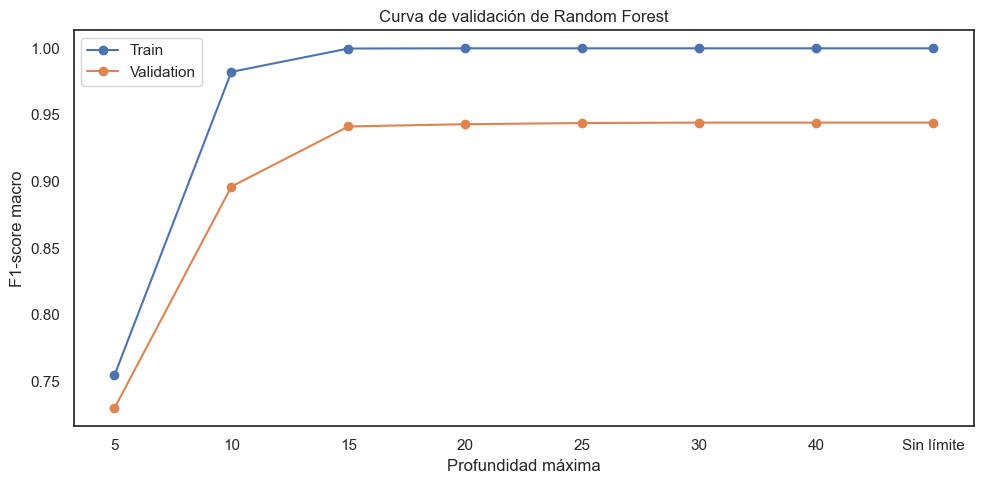

In [6]:
profundidades_curva = [5, 10, 15, 20, 25, 30, 40, None]
resultados_curva = []

for profundidad in profundidades_curva:
    modelo_curva = RandomForestClassifier(
        n_estimators=200,
        max_depth=profundidad,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    modelo_curva.fit(X_train, y_train)

    pred_train = modelo_curva.predict(X_train)
    pred_validation = modelo_curva.predict(X_validation)

    resultados_curva.append({
        "max_depth": "Sin límite" if profundidad is None else str(profundidad),
        "f1_train": f1_score(y_train, pred_train, average="macro"),
        "f1_validation": f1_score(
            y_validation,
            pred_validation,
            average="macro"
        )
    })

tabla_curva = pd.DataFrame(resultados_curva)
display(tabla_curva.round(4))

posiciones = np.arange(len(tabla_curva))

plt.figure(figsize=(10, 5))
plt.plot(
    posiciones,
    tabla_curva["f1_train"],
    marker="o",
    label="Train"
)
plt.plot(
    posiciones,
    tabla_curva["f1_validation"],
    marker="o",
    label="Validation"
)
plt.xticks(posiciones, tabla_curva["max_depth"])
plt.title("Curva de validación de Random Forest")
plt.xlabel("Profundidad máxima")
plt.ylabel("F1-score macro")
plt.legend()
plt.tight_layout()
plt.show()


### Interpretación de la curva

Con `max_depth=5`, los F1 macro de train y validation fueron **0.7545** y **0.7299**, lo que indica subajuste. Al aumentar la profundidad, ambos resultados mejoraron.

Desde profundidad 20, train alcanzó 1.0000. Validation continuó aumentando: 0.9431 con profundidad 20, 0.9439 con 25 y **0.9443 con 30, 40 y sin límite**. La curva muestra una brecha, pero validation no disminuye con árboles más profundos; se estabiliza.

Por lo tanto, limitar la profundidad no mejoró la generalización. La configuración sin límite empata con 30 y 40 en el mejor resultado de validation, lo que respalda la selección obtenida durante la búsqueda de hiperparámetros.

## 9. Entrenamiento final y evaluación única en test

Una vez seleccionados los hiperparámetros, se unirán entrenamiento y validación. El Random Forest final se ajustará con todos esos datos de desarrollo y se evaluará una sola vez sobre prueba.

Esta evaluación representa la estimación final del desempeño porque las etiquetas de prueba no participaron en la comparación de modelos ni en la selección de hiperparámetros.


In [7]:
X_desarrollo = np.concatenate(
    [X_train, X_validation],
    axis=0
)
y_desarrollo = np.concatenate(
    [y_train, y_validation],
    axis=0
)

modelo_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=mejores_parametros["max_depth"],
    min_samples_split=mejores_parametros["min_samples_split"],
    min_samples_leaf=mejores_parametros["min_samples_leaf"],
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

modelo_final.fit(X_desarrollo, y_desarrollo)
predicciones_test = modelo_final.predict(X_test)

exactitud_test = accuracy_score(y_test, predicciones_test)
precision_macro_test = precision_score(
    y_test,
    predicciones_test,
    average="macro",
    zero_division=0
)
f1_macro_test = f1_score(
    y_test,
    predicciones_test,
    average="macro"
)

print(f"Exactitud final en test: {exactitud_test:.4f}")
print(f"Precisión macro final en test: {precision_macro_test:.4f}")
print(f"F1 macro final en test: {f1_macro_test:.4f}")


Exactitud final en test: 0.9563
Precisión macro final en test: 0.9549
F1 macro final en test: 0.9531


### Interpretación del resultado final

Después de unir entrenamiento y validación, el Random Forest final obtuvo en test una exactitud de **0.9563**, precisión macro de **0.9549** y F1 macro de **0.9531**.

Estas métricas representan la evaluación final, ya que test no intervino en la comparación de algoritmos ni en la selección de hiperparámetros. La cercanía entre precisión y F1 macro indica un desempeño relativamente consistente entre las 16 actividades.


## 10. Evaluación detallada final

Se mostrará el reporte por actividad y la matriz de confusión del Random Forest final. Estas salidas permiten identificar las clases con mejor desempeño y las confusiones que todavía permanecen.


,precision,recall,f1-score,support
000,1.0000,0.9931,0.9965,144.0000
001,0.8805,0.9211,0.9003,152.0000
002,0.9355,0.8529,0.8923,136.0000
003,0.9623,0.9562,0.9592,160.0000
004,0.9862,0.9773,0.9817,220.0000
005,0.9780,0.9911,0.9845,224.0000
006,0.8852,0.9643,0.9231,168.0000
007,0.9776,0.9903,0.9839,308.0000
008,0.9825,0.9375,0.9595,240.0000
009,0.9328,0.9672,0.9497,244.0000


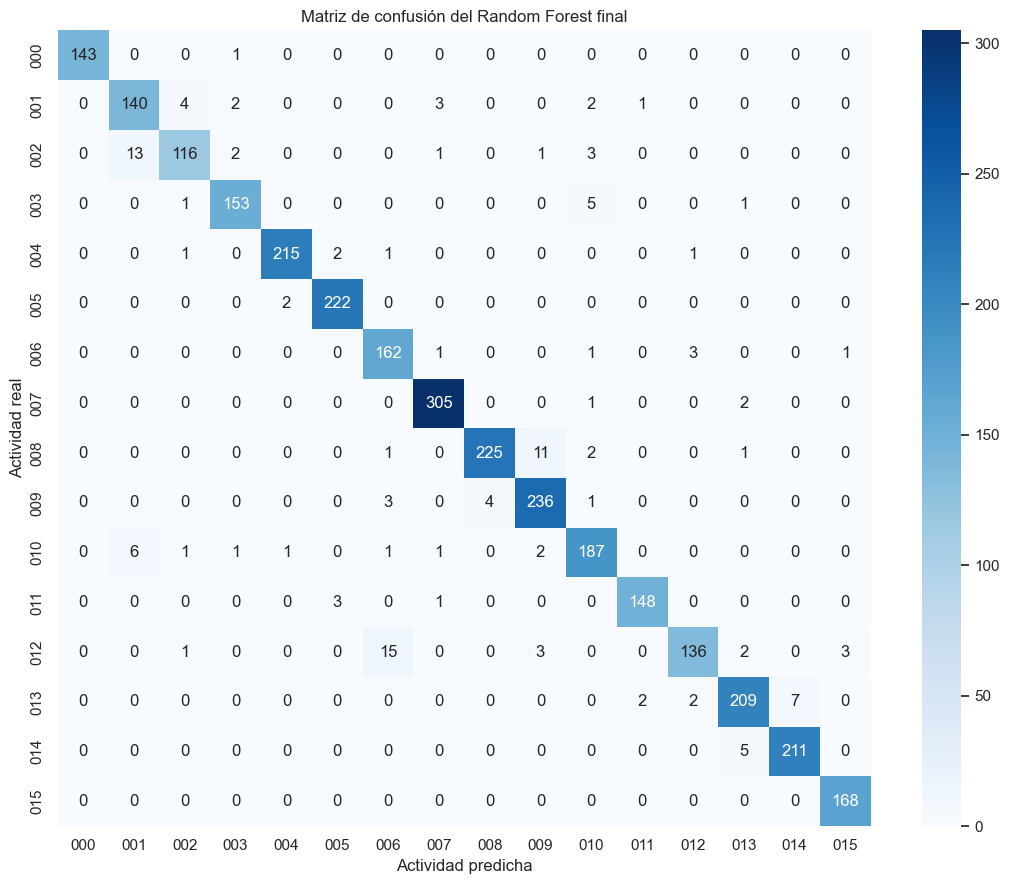

In [8]:
actividades = np.sort(np.unique(y_test))

reporte_final = classification_report(
    y_test,
    predicciones_test,
    labels=actividades,
    output_dict=True,
    zero_division=0
)

display(pd.DataFrame(reporte_final).transpose().round(4))

matriz_final = confusion_matrix(
    y_test,
    predicciones_test,
    labels=actividades
)

plt.figure(figsize=(11, 9))
sns.heatmap(
    matriz_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=actividades,
    yticklabels=actividades
)
plt.title("Matriz de confusión del Random Forest final")
plt.xlabel("Actividad predicha")
plt.ylabel("Actividad real")
plt.tight_layout()
plt.show()


### Interpretación de la evaluación detallada

El modelo final mantuvo un desempeño alto en las 16 actividades. La actividad `000` obtuvo un F1 de **0.9965**. Las actividades que requieren mayor atención son `002`, con F1 de **0.8923**, y `012`, con recall de **0.8500**.

La concentración de valores en la diagonal de la matriz indica que la mayoría de las ventanas se clasificó correctamente. Los valores fuera de la diagonal permiten identificar las parejas de actividades que todavía generan confusión.

## 11. Decisión final

La separación en train, validation y test permitió asignar una función específica a cada conjunto. Train se utilizó para ajustar los modelos, el conjunto fijo de validation para comparar algoritmos y seleccionar hiperparámetros sin cross-validation, y test únicamente para la evaluación final.

Random Forest fue el mejor modelo en validation y la optimización volvió a seleccionar su configuración inicial. Después de reajustarlo con train y validation, alcanzó **95.63% de exactitud** y **0.9531 de F1 macro** en test. Estos resultados son muy similares a los obtenidos con la estrategia anterior, pero esta prueba proporciona una separación más clara entre selección y evaluación final.
